## 데이터 전처리 시작

In [1]:
import os
from google.colab import drive, auth
import zipfile

# Google Drive 마운트 및 API 인증
drive.mount('/content/drive')
auth.authenticate_user() # Google Drive API 사용을 위한 인증

# 저장할 구글 드라이브 폴더 ID (사용자가 제공한 URL에서 추출)
drive_folder_id = '1teiRbwW4ciSrKLd4bvs7kc81Y5q3lkwV'

# 로컬 저장 경로 설정
output_dir = '/content/output_files'
os.makedirs(output_dir, exist_ok=True)

Mounted at /content/drive


In [2]:
#통합된 데이터 사용

import pandas as pd
df = pd.read_pickle('/content/레몬테라스_에어컨 구매.pickle')
print(df.head())

                                     title  \
0                      전자랜드나 하이마트와 인터넷으로~    
1         (용인) 이사하면서 가전제품 삼성 풀세트로 맞췄어요 ㅎㅎ    
2                         다들 에어컨 청소 하시나요?    
3   (수정) 전 세입자가 협의 없이 설치한 붙박이장 살까요 말까요 ㅎㅎ    
4               쓸만한 에어컨 세탁기 바꿀때 그냥 버리시나요?    

                                             content  \
0  \n에어컨구매시 매장과 인터넷. 설치비 차이가​있나요?​가격은 천차만별인데 인터넷은...   
1  \n가전은 엘지냐 삼성이냐 계속 두고 고민하면서 온라인 쇼핑가격 찾아보고 하다가 삼...   
2  \n할까말까 고민중이었는데, ​동네분들 어디서하나 요기조기 견적도 받아보고​알아보다...   
3  \n앗 댓글들 모두 감사드립니다원복요청해야겠네요. 어찌저찌 놔두고 공사가 가능하려나...   
4  \n에어컨 세탁기 .. 잘돌아가고 문제없고 구매 5년된 건데당근에 내놔도 될까요?우...   

                                             comment         date view  \
0                                                 []  2026.03.10.   18   
1                                                 []  2026.03.09.   42   
2                                               [광고]  2026.03.06.   59   
3                                                 []  2026.03.05.  155   
4  [네 당근으로 하세요~\

In [3]:
!pip install kiwipiepy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 MB 9.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 24.9 MB/s eta 0:00:00
  Created wheel for kiwipiepy_model: filename=kiwipiepy_model-0.22.1-py3-none-any.whl size=79578111 sha256=b322e6173fa432cb15b4974ceee0820a3328ce1086edd52b08ccbe2d06668761
  Stored in directory: /root/.cache/pip/wheels/c0/5a/4b/a1abeb73f3d31c5d010d4163bc08686d5539766084ecba0e1a
Successfully built kiwipiepy_model


In [4]:
import re
import pandas as pd
from kiwipiepy import Kiwi

# ----------------------------
# 0. 형태소 분석기 로드
# ----------------------------
kiwi = Kiwi()

# ----------------------------
# 1. 데이터 전처리 - 중복 제거 / NaN 처리
# ----------------------------
def preprocess_dataframe(df, text_col='review'):
    """
    - text_col 기준 NaN 제거
    - 공백 문자열 제거
    - 중복 제거
    """
    df = df.copy()

    # NaN 제거
    df = df.dropna(subset=[text_col])

    # 문자열 변환 + 양쪽 공백 제거
    df[text_col] = df[text_col].astype(str).str.strip()

    # 빈 문자열 제거
    df = df[df[text_col] != ""]

    # 중복 제거
    df = df.drop_duplicates(subset=[text_col]).reset_index(drop=True)

    return df


# ----------------------------
# 2. 클렌징
# ----------------------------
def clean_korean_text(
    text,
    keep_num=True,          # 숫자 유지 여부
    keep_emo=True,          # ㅋㅋ, ㅎㅎ, ㅠㅠ, ㅜㅜ 같은 감정표현 유지 여부
    keep_hashtag_text=True, # #여행 -> 여행 으로 살릴지 여부
    normalize_repeat=True   # 반복 문자 정규화 여부
):
    """
    한국어 텍스트 클렌징 함수
    """
    if text is None:
        return ""

    text = str(text)

    # 1. HTML 태그 제거
    text = re.sub(r'<[^>]+>', ' ', text)

    # 2. URL 제거
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    # 3. 이메일 제거
    text = re.sub(r'[\w\.-]+@[\w\.-]+\.\w+', ' ', text)

    # 4. @멘션 제거
    text = re.sub(r'@\w+', ' ', text)

    # 5. 해시태그 처리
    if keep_hashtag_text:
        text = re.sub(r'#([가-힣a-zA-Z0-9_]+)', r'\1', text)
    else:
        text = re.sub(r'#[가-힣a-zA-Z0-9_]+', ' ', text)

    # 6. 줄바꿈 / 탭 정리
    text = re.sub(r'[\n\r\t]', ' ', text)

    # 7. 반복되는 문장부호 정규화
    # !!!!! -> !
    # ????? -> ?
    # ...... -> .
    # ~~~~~ -> ~
    if normalize_repeat:
        text = re.sub(r'([!?.,~])\1+', r'\1', text)

    # 8. 감정 표현 정규화
    # ㅋㅋㅋㅋ -> ㅋㅋ / ㅎㅎㅎㅎ -> ㅎㅎ / ㅠㅠㅠ -> ㅠㅠ / ㅜㅜㅜ -> ㅜㅜ
    if normalize_repeat:
        text = re.sub(r'ㅋ{3,}', 'ㅋㅋ', text)
        text = re.sub(r'ㅎ{3,}', 'ㅎㅎ', text)
        text = re.sub(r'ㅠ{3,}', 'ㅠㅠ', text)
        text = re.sub(r'ㅜ{3,}', 'ㅜㅜ', text)

    # 9. 감정표현 placeholder 처리
    if keep_emo:
        text = text.replace('ㅋㅋ', ' EMO_KK ')
        text = text.replace('ㅎㅎ', ' EMO_HH ')
        text = text.replace('ㅠㅠ', ' EMO_TT ')
        text = text.replace('ㅜㅜ', ' EMO_UU ')

    # 10. 숫자 유지 여부에 따라 허용 문자 범위 조정
    if keep_num:
        # 한글, 영문, 숫자, 공백만 남김
        text = re.sub(r'[^가-힣a-zA-Z0-9\s]', ' ', text)
    else:
        # 한글, 영문, 공백만 남김
        text = re.sub(r'[^가-힣a-zA-Z\s]', ' ', text)

    # 11. 의미 없는 자음/모음 토큰 제거
    # ex. ㄱㄱ, ㅇㅇ, ㅏㅏ
    text = re.sub(r'\b[ㄱ-ㅎㅏ-ㅣ]+\b', ' ', text)

    # 12. placeholder 복원
    if keep_emo:
        text = text.replace('EMO_KK', 'ㅋㅋ')
        text = text.replace('EMO_HH', 'ㅎㅎ')
        text = text.replace('EMO_TT', 'ㅠㅠ')
        text = text.replace('EMO_UU', 'ㅜㅜ')

    # 13. 공백 정리
    text = re.sub(r'\s+', ' ', text).strip()

    return text


# ----------------------------
# 3. 토큰화
# ----------------------------
def tokenize_korean_basic(text):
    """
    한국어 텍스트에서
    - 일반명사(NNG)
    - 고유명사(NNP)
    - 동사(VV)
    - 형용사(VA)
    만 남기는 1차 토큰화 함수
    """
    if text is None:
        return []

    text = str(text).strip()
    if text == "":
        return []

    tokens = kiwi.tokenize(text)

    allowed_tags = {'NNG', 'NNP', 'VV', 'VA'}

    result = []
    for token in tokens:
        if token.tag in allowed_tags:
            word = token.form

            # 동사/형용사는 기본형 느낌으로 맞추기
            if token.tag in {'VV', 'VA'} and not word.endswith('다'):
                word = word + '다'

            result.append(word)

    return result


# ----------------------------
# 4. 필터링 / stopwords / 철자 수정
# ----------------------------

# 4-1. 줄임말 / 오타 / 구어체 치환 사전
normalize_dict = {
    # 줄임말
    '넘': '너무',
    '넘나': '너무',
    '걍': '그냥',
    '글케': '그렇게',
    '글쿠나': '그렇구나',
    '글쿤': '그렇군',
    '머': '뭐',
    '뭔가': '무언가',
    '왤케': '왜이렇게',
    '왠지': '왜인지',
    '글애': '그래',
    '글치': '그렇지',
    '글치만': '그렇지만',
    '겁나': '매우',
    '개좋다': '매우좋다',
    '개웃기다': '매우웃기다',

    # 오타
    '재밋다': '재밌다',
    '재밌따': '재밌다',
    '잼있다': '재밌다',
    '맛잇다': '맛있다',
    '맛있따': '맛있다',
    '잇다': '있다',
    '업다': '없다',
    '조타': '좋다',
    '조흐다': '좋다',
    '갠찮다': '괜찮다',
    '괸찮다': '괜찮다',
    '귀찬다': '귀찮다',
    '편한하다': '편안하다',
    '불편햇다': '불편하다',
    '좋앗다': '좋다',
    '좋아요오': '좋다',

    # 구어체 / 축약 표현
    '했음': '하다',
    '했슴': '하다',
    '했네용': '하다',
    '했어요용': '하다',
    '좋네용': '좋다',
    '좋아용': '좋다',
    '있어용': '있다',
    '없어용': '없다',
    '같아용': '같다',

    # 반응 표현 -> 의미어 변환
    '짱': '최고',
    '최고다': '최고',
    '굿': '좋다',
    '굳': '좋다',
    '쏘쏘': '보통',
}

# 4-2. 기본 불용어
basic_stopwords = {
    '것', '수', '등', '때', '점', '좀', '거', '곳', '부분',
    '경우', '정도', '관련', '이용', '사용', '처음', '나중',
    '이번', '저번', '여기', '저기', '무언가', '뭔가'
}

# 4-3. 구어체 불용어
casual_stopwords = {
    '진짜', '너무', '정말', '완전', '약간', '그냥', '살짝',
    '엄청', '매우', '되게', '조금', '많이', '막', '또', '더',
    '아주', '약간은', '사실', '뭐', '음', '아', '어', '오'
}

# 4-4. 반응 표현 제거
reaction_stopwords = {
    'ㅋㅋ', 'ㅎㅎ', 'ㅠㅠ', 'ㅜㅜ'
}

# 4-5. 의미 약한 일반 용언
weak_verbs_adjs = {
    '하다', '되다', '있다', '없다', '같다', '보다',
    '가다', '오다', '주다', '받다', '나다', '말하다',
    '생각하다', '느끼다', '알다', '모르다'
}

# 통합 stopwords
all_stopwords = basic_stopwords | casual_stopwords | reaction_stopwords | weak_verbs_adjs


def normalize_token(token, normalize_dict=normalize_dict):
    """
    토큰 1개를 줄임말/오타/구어체 기준으로 정규화
    """
    token = token.strip()

    # 1. 사전 치환
    token = normalize_dict.get(token, token)

    # 2. 반복 문자 정규화
    # ex. 좋다아아 -> 좋다 / 최고오오 -> 최고
    token = re.sub(r'(.)\1{2,}', r'\1', token)

    return token


def filter_normalize_tokens(
    tokens,
    stopwords=all_stopwords,
    normalize_dict=normalize_dict,
    min_len=2
):
    """
    토큰 리스트를 받아
    - 오타/줄임말 정규화
    - stopwords 제거
    - 짧은 토큰 제거
    - 숫자만 있는 토큰 제거
    수행
    """
    results = []

    for token in tokens:
        # 1. 정규화
        token = normalize_token(token, normalize_dict)

        # 2. 빈값 제거
        if not token or token.strip() == '':
            continue

        # 3. 숫자만 있는 토큰 제거
        if token.isdigit():
            continue

        # 4. 길이 필터
        if len(token) < min_len:
            continue

        # 5. stopwords 제거
        if token in stopwords:
            continue

        results.append(token)

    return results


# ----------------------------
# 5. stemming / lemma 정규화
# ----------------------------
def stem_korean_tokens(tokens):
    """
    한국어 토큰 리스트를 받아
    동사/형용사를 기본형(lemma)으로 변환
    명사는 그대로 유지
    """
    results = []

    for token in tokens:
        analysis = kiwi.analyze(token)

        if not analysis:
            results.append(token)
            continue

        # 첫 번째 후보의 형태소 리스트만 꺼내기
        best_segmentation = analysis[0][0]

        lemmas = []
        for token_obj in best_segmentation:
            form = token_obj.form
            tag = token_obj.tag

            if tag in {'VV', 'VA'}:
                if not form.endswith('다'):
                    form = form + '다'
                lemmas.append(form)
            elif tag.startswith('NN'):
                lemmas.append(form)

        if lemmas:
            results.extend(lemmas)
        else:
            results.append(token)

    return results


# ----------------------------
# 6. 토큰 후처리
# ----------------------------
def postprocess_tokens(tokens, remove_duplicates=False):
    """
    - 빈 토큰 제거
    - remove_duplicates=True면 문서 내 중복 토큰 제거(순서 유지)
    """
    tokens = [t for t in tokens if isinstance(t, str) and t.strip() != ""]

    if remove_duplicates:
        seen = set()
        unique_tokens = []
        for t in tokens:
            if t not in seen:
                seen.add(t)
                unique_tokens.append(t)
        return unique_tokens

    return tokens


# ----------------------------
# 7. 전체 파이프라인
# ----------------------------
def full_korean_nlp_pipeline(
    df,
    text_col='review',
    keep_num=True,
    keep_emo=True,
    keep_hashtag_text=True,
    normalize_repeat=True,
    min_len=2,
    remove_duplicates=False
):
    """
    전체 전처리 파이프라인:
    1) NaN/중복 제거
    2) 클렌징
    3) 토큰화
    4) 필터링/정규화
    5) stemming
    6) 토큰 후처리
    7) 추가: 토큰이 없는 문서 제거
    8) 추가: 최종 토큰 문자열 중복 제거
    """

    # 1. 기본 전처리
    df = preprocess_dataframe(df, text_col=text_col)

    # 2. 클렌징
    df['clean_text'] = df[text_col].apply(
        lambda x:
            clean_korean_text(
            x,
            keep_num=keep_num,
            keep_emo=keep_emo,
            keep_hashtag_text=keep_hashtag_text,
            normalize_repeat=normalize_repeat
        )
    )

    # 3. 토큰화
    df['tokens_1st'] = df['clean_text'].apply(tokenize_korean_basic)

    # 4. 필터링 / stopwords / 철자 수정
    df['tokens_filtered'] = df['tokens_1st'].apply(
        lambda x:
            filter_normalize_tokens(
            x,
            stopwords=all_stopwords,
            normalize_dict=normalize_dict,
            min_len=min_len
        )
    )

    # 5. stemming / lemma
    df['tokens_stemmed'] = df['tokens_filtered'].apply(stem_korean_tokens)

    # 6. 토큰 후처리
    df['tokens_final'] = df['tokens_stemmed'].apply(
        lambda x: postprocess_tokens(x, remove_duplicates=remove_duplicates)
    )

    # 7. TF-IDF 입력용 문자열
    df['text_for_tfidf'] = df['tokens_final'].apply(lambda x: ' '.join(x))

    # --- 추가된 로직 ---
    # 8. 최종 토큰이 없는 문서 제거 (빈 리스트 제거)
    print(f"[파이프라인] 빈 토큰 리스트 문서 제거 전 행 수: {len(df)}")
    df = df[df['tokens_final'].apply(len) > 0]
    print(f"[파이프라인] 빈 토큰 리스트 문서 제거 후 행 수: {len(df)}")

    # 9. text_for_tfidf (최종 토큰 문자열) 기준 중복 제거
    print(f"[파이프라인] 최종 토큰 문자열 중복 제거 전 행 수: {len(df)}")
    df = df.drop_duplicates(subset=['text_for_tfidf']).reset_index(drop=True)
    print(f"[파이프라인] 최종 토큰 문자열 중복 제거 후 행 수: {len(df)}")
    # --- 추가된 로직 끝 ---

    return df

In [5]:
result_df = full_korean_nlp_pipeline(
    df,
    text_col='content', #칼럼명 다르면 변경해주기!
    keep_num=True,
    keep_emo=True,
    keep_hashtag_text=True,
    normalize_repeat=True,
    min_len=2,
    remove_duplicates=False
)

sentences = result_df['tokens_final'].tolist()

[파이프라인] 빈 토큰 리스트 문서 제거 전 행 수: 1220
[파이프라인] 빈 토큰 리스트 문서 제거 후 행 수: 1211
[파이프라인] 최종 토큰 문자열 중복 제거 전 행 수: 1211
[파이프라인] 최종 토큰 문자열 중복 제거 후 행 수: 1204


In [6]:
result_df

,title,content,comment,date,view,url,clean_text,tokens_1st,tokens_filtered,tokens_stemmed,tokens_final,text_for_tfidf
0,전자랜드나 하이마트와 인터넷으로~,에어컨구매시 매장과 인터넷. 설치비 차이가​있나요?​가격은 천차만별인데 인터넷은 설...,[],2026.03.10.,18,https://cafe.naver.com/f-e/cafes/10298136/arti...,에어컨구매시 매장과 인터넷 설치비 차이가 있나요 가격은 천차만별인데 인터넷은 설치비...,"[에어컨, 구매, 매장, 인터넷, 설치비, 차이, 있다, 가격, 천차만별, 인터넷,...","[에어컨, 구매, 매장, 인터넷, 설치비, 차이, 가격, 천차만별, 인터넷, 설치비...","[에어컨, 구매, 매장, 인터넷, 설치비, 차이, 가격, 천차만별, 인터넷, 설치비...","[에어컨, 구매, 매장, 인터넷, 설치비, 차이, 가격, 천차만별, 인터넷, 설치비...",에어컨 구매 매장 인터넷 설치비 차이 가격 천차만별 인터넷 설치비 어마 나오다
1,(용인) 이사하면서 가전제품 삼성 풀세트로 맞췄어요 ㅎㅎ,가전은 엘지냐 삼성이냐 계속 두고 고민하면서 온라인 쇼핑가격 찾아보고 하다가 삼성가...,[],2026.03.09.,42,https://cafe.naver.com/f-e/cafes/10298136/arti...,가전은 엘지냐 삼성이냐 계속 두고 고민하면서 온라인 쇼핑가격 찾아보고 하다가 삼성가...,"[가전, 엘지, 삼성, 두다, 고민, 온라인, 쇼핑, 가격, 찾아보다, 하다, 삼성...","[가전, 엘지, 삼성, 두다, 고민, 온라인, 쇼핑, 가격, 찾아보다, 삼성, 상담...","[가전, 엘지, 삼성, 두다, 고민, 온라인, 쇼핑, 가격, 찾아보다, 삼성, 상담...","[가전, 엘지, 삼성, 두다, 고민, 온라인, 쇼핑, 가격, 찾아보다, 삼성, 상담...",가전 엘지 삼성 두다 고민 온라인 쇼핑 가격 찾아보다 삼성 상담 스펙 세트 좋다 가...
2,다들 에어컨 청소 하시나요?,"할까말까 고민중이었는데, ​동네분들 어디서하나 요기조기 견적도 받아보고​알아보다가 ...",[광고],2026.03.06.,59,https://cafe.naver.com/f-e/cafes/10298136/arti...,할까말까 고민중이었는데 동네분들 어디서하나 요기조기 견적도 받아보고 알아보다가 업체...,"[하다, 말다, 고민, 동네, 하다, 견적, 알아보다, 업체, 결정, 청소, 점심때...","[말다, 고민, 동네, 견적, 알아보다, 업체, 결정, 청소, 점심때, 따땃, 여름...","[말, 고민, 동네, 견적, 알아보다, 업체, 결정, 청소, 점심, 때, 따땃, 여...","[말, 고민, 동네, 견적, 알아보다, 업체, 결정, 청소, 점심, 때, 따땃, 여...",말 고민 동네 견적 알아보다 업체 결정 청소 점심 때 따땃 여름 바쁘다 벽걸이 추가...
3,(수정) 전 세입자가 협의 없이 설치한 붙박이장 살까요 말까요 ㅎㅎ,앗 댓글들 모두 감사드립니다원복요청해야겠네요. 어찌저찌 놔두고 공사가 가능하려나 싶...,[],2026.03.05.,155,https://cafe.naver.com/f-e/cafes/10298136/arti...,앗 댓글들 모두 감사드립니다원복요청해야겠네요 어찌저찌 놔두고 공사가 가능하려나 싶었...,"[댓글, 감사, 드리다, 원, 복, 요청, 놔두다, 공사, 가능, 전체, 철거, 댓...","[댓글, 감사, 드리다, 요청, 놔두다, 공사, 가능, 전체, 철거, 댓글, 정신,...","[댓글, 감사, 드리다, 요청, 놔두다, 공사, 가능, 전체, 철거, 댓글, 정신,...","[댓글, 감사, 드리다, 요청, 놔두다, 공사, 가능, 전체, 철거, 댓글, 정신,...",댓글 감사 드리다 요청 놔두다 공사 가능 전체 철거 댓글 정신 들다 인테리어 무지 ...
4,쓸만한 에어컨 세탁기 바꿀때 그냥 버리시나요?,에어컨 세탁기 .. 잘돌아가고 문제없고 구매 5년된 건데당근에 내놔도 될까요?우리집...,[네 당근으로 하세요~\n싸게 내놓으면 바로 팔려요.\n혹시 새로 가전바꿀때 밑으로...,2026.03.05.,71,https://cafe.naver.com/f-e/cafes/10298136/arti...,에어컨 세탁기 잘돌아가고 문제없고 구매 5년된 건데당근에 내놔도 될까요 우리집에선 ...,"[에어컨, 세탁기, 돌아가다, 문제없다, 구매, 되다, 당근, 내다, 되다, 집, ...","[에어컨, 세탁기, 돌아가다, 문제없다, 구매, 당근, 내다, 가져가다, 이유, 문...","[에어컨, 세탁기, 돌아가다, 문제없다, 구매, 당근, 내다, 가져가다, 이유, 문...","[에어컨, 세탁기, 돌아가다, 문제없다, 구매, 당근, 내다, 가져가다, 이유, 문...",에어컨 세탁기 돌아가다 문제없다 구매 당근 내다 가져가다 이유 문제 생기다 귀찮다 ...
...,...,...,...,...,...,...,...,...,...,...,...,...
1199,에어컨 실외기 크기,이사 간 집이 실외기 거치대가 작아서 에어컨 설치를 못하고맀어요 ㅠㅠㅠㅠ 집주인은 ...,"[규격설치가 뭔가요??, ㅠㅠㅠ건물 지을때 설치해놓은거 같은데 좀 큰거로 하지 집주...",2021.04.24.,"1,416",https://cafe.naver.com/f-e/cafes/10298136/arti...,이사 간 집이 실외기 거치대가 작아서 에어컨 설치를 못하고맀어요 EMO TT 집주인...,"[이사, 가다, 집, 실외, 거치대, 작다, 에어컨, 설치, 하다, 맀, 집주인, ...","[이사, 실외, 거치대, 작다, 에어컨, 설치, 집주인, 거치대, 에어컨, 설치, ...","[이사, 실외, 거치대, 작다, 에어컨, 설치, 집주인, 거치대, 에어컨, 설치, ...","[이사, 실외, 거치대, 작다, 에어컨, 설치, 집주인, 거치대, 에어컨, 설치, ...",이사 실외 거치대 작다 에어컨 설치 집주인 거치대 에어컨 설치 기사 구매 에어컨 실...
1200,에어컨 구매방법~,지금 쓰고 있는 에어컨이 너무 오래돼서 새로 구매하려고 하는데​어디서 구매하는게 저...,[],2021.04.23.,37,https://cafe.naver.com/f-e/cafes/10298136/arti...,지금 쓰고 있는 에어컨이 너무 오래돼서 새로 구매하려고 하는데 어디서 구매하는게 저...,"[쓰다, 에어컨, 되다, 구매, 구매, 가용]","[쓰다, 에어컨, 구매, 구매, 가용]","[쓰다, 에어컨, 구매, 구매, 가용]","[쓰다, 에어컨, 구매, 구매, 가용]",쓰다 에어컨 구매 구매 가용
1201,"분양아파트 옵션 질문드려요~(식세기, 오븐)","안녕하세요? 며칠전에 레테님들께 인덕션 문의드렸는데, 정말 많은 도움 되었어요~! ...",[검색해보니 인터넷 최저가보다 싸더라구요.. 댓글 감사합니다. 많은 도움 되었습니다...,2021.04.22.,859,https://cafe.naver.com/f-e/cafes/10298136/arti...,안녕하세요 며칠전에 레테님들께 인덕션 문의드렸는데 정말 많은 도움 되었어요 역시 여...,"[안녕, 며칠, 전, 레테, 인덕션, 문의, 드리다, 많다, 도움, 되다, 유상, ...","[안녕, 며칠, 레테, 인덕션, 문의, 드리다, 많다, 도움, 유상, 옵션, 주방,...","[안녕, 며칠, 레테, 인덕션, 문의, 드리다, 많다, 도움, 유상, 옵션, 주방,...","[안녕, 며칠, 레테, 인덕션, 문의, 드리다, 많다, 도움, 유상, 옵션, 주방,...",안녕 며칠 레테 인덕션 문의 드리다 많다 도움 유상 옵션 주방 상판 엔지니어 스톤 ...
1202,에어컨 구매~,에어컨을 사려고 하는데요!!혹시 이미 사신분들께 조언을 구합니다.저희집은 1층이라 ...,"[요즘은 4등급이 1등급이에요, 저희집은 그래요ㅠ다른 1층은 안그럴수도 있지만..오...",2021.04.21.,222,https://cafe.naver.com/f-e/cafes/10298136/arti...,에어컨을 사려고 하는데요 혹시 이미 사신분들께 조언을

In [7]:
columns_to_save = ['content', 'tokens_final']
saved_df = result_df[columns_to_save].copy()

# Pickle 파일로 저장
saved_df.to_pickle('/content/token.pickle')
print('선택된 칼럼들이 /content/token.pickle 파일로 저장되었습니다.')

# CSV 파일로 저장
saved_df.to_csv('/content/token.csv', index=False)
print('선택된 칼럼들이 /content/token.csv 파일로 저장되었습니다.')

선택된 칼럼들이 /content/token.pickle 파일로 저장되었습니다.
선택된 칼럼들이 /content/token.csv 파일로 저장되었습니다.


## 토큰화된 데이터 저장 완료

최종 사용 칼럼은 ' tokens_final ' 로 진행

나머지는 혹시 몰라서 남겨두었으니 확인

In [8]:
!pip install --upgrade scipy
!pip install --upgrade gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 21.3 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 83.6 MB/s eta 0:00:00


In [9]:
import gensim #자연어 처리 및 토픽 모델링을 위한 라이브러리
from gensim.models.doc2vec import TaggedDocument
from gensim.models import Doc2Vec

## Doc2Vec 준비

In [10]:
tagged_corpus_list = []

for n, i in enumerate(result_df['tokens_final']):
    tag = f'document{n}'
    tagged_corpus_list.append(TaggedDocument(tags=[tag], words=i))

In [11]:
#잘 나왔나 확인
tagged_corpus_list[0]

TaggedDocument(words=['에어컨', '구매', '매장', '인터넷', '설치비', '차이', '가격', '천차만별', '인터넷', '설치비', '어마', '나오다'], tags=['document0'])

## Doc2Vec 학습시키기

In [12]:
#모델선언
from gensim.models.doc2vec import Doc2Vec

# 모델 선언
model_doc2vec = Doc2Vec(
    vector_size=200,   # 문서 임베딩 벡터 차원
    window=5,          # 앞뒤 단어 몇 개를 문맥으로 볼 것인지
    min_count=2,       # 최소 등장 단어 수 (노이즈 단어 제거)
    epochs=50,         # 전체 데이터 반복 학습 횟수
    alpha=0.025,       # 초기 학습률
    min_alpha=0.0005,  # 최소 학습률 (학습하면서 감소)
    dm=1,              # 1: 문맥 기반(PV-DM), 0: 단어벡터합(PV-DBOW)
    dm_mean=1,         # context 단어 평균 사용
    negative=5,        # negative sampling 개수
    sample=1e-5,       # 고빈도 단어 downsampling
    hs=0,              # hierarchical softmax 사용 여부
    workers=4          # CPU 병렬 처리
)

In [13]:
#단어 사전 설정
model_doc2vec.build_vocab(tagged_corpus_list)

In [14]:
#벡터 학습
model_doc2vec.train(tagged_corpus_list,
                    total_examples = model_doc2vec.corpus_count,
                    epochs = model_doc2vec.epochs)

In [15]:
#document vector 확인
model_doc2vec.dv['document0']

array([-0.00942451, -0.03572766,  0.01698597,  0.00897983,  0.02850208,
       -0.00558598, -0.01865686,  0.04042137, -0.03332827,  0.03165061,
       -0.01510673, -0.02483717,  0.00344784,  0.00916102,  0.00537207,
       -0.03424282, -0.01607289, -0.00954182,  0.00100117, -0.04278038,
        0.01552344, -0.01601137,  0.00497283, -0.01190433,  0.01811616,
       -0.03429323,  0.00925681,  0.00821472, -0.04601847, -0.0338987 ,
        0.02652866, -0.01120088, -0.02063794,  0.00186294,  0.00929074,
        0.01514391,  0.02751386, -0.0030642 ,  0.03030087, -0.03854059,
       -0.00298248,  0.00666699,  0.02044593, -0.01424558,  0.02291336,
       -0.0250991 , -0.00453349, -0.02387635, -0.01195504,  0.01931674,
       -0.0081827 , -0.00949255,  0.00267526, -0.02515167, -0.00872687,
       -0.01696001,  0.0012484 ,  0.00044816, -0.03960846,  0.00591826,
       -0.02319205, -0.00057348, -0.04591247,  0.03269302, -0.0078179 ,
        0.02693305,  0.02164198,  0.01760263,  0.00561894,  0.02

In [16]:
from tqdm import tqdm

vector_list = []

for i in tqdm(range(len(result_df))):
    vec = model_doc2vec.dv[f'document{i}']
    vector_list.append(vec)

100%|██████████| 1204/1204 [00:00<00:00, 169268.02it/s]


In [17]:
result_df['vector'] = vector_list
result_df.head()

,title,content,comment,date,view,url,clean_text,tokens_1st,tokens_filtered,tokens_stemmed,tokens_final,text_for_tfidf,vector
0,전자랜드나 하이마트와 인터넷으로~,에어컨구매시 매장과 인터넷. 설치비 차이가​있나요?​가격은 천차만별인데 인터넷은 설...,[],2026.03.10.,18,https://cafe.naver.com/f-e/cafes/10298136/arti...,에어컨구매시 매장과 인터넷 설치비 차이가 있나요 가격은 천차만별인데 인터넷은 설치비...,"[에어컨, 구매, 매장, 인터넷, 설치비, 차이, 있다, 가격, 천차만별, 인터넷,...","[에어컨, 구매, 매장, 인터넷, 설치비, 차이, 가격, 천차만별, 인터넷, 설치비...","[에어컨, 구매, 매장, 인터넷, 설치비, 차이, 가격, 천차만별, 인터넷, 설치비...","[에어컨, 구매, 매장, 인터넷, 설치비, 차이, 가격, 천차만별, 인터넷, 설치비...",에어컨 구매 매장 인터넷 설치비 차이 가격 천차만별 인터넷 설치비 어마 나오다,"[-0.0094245095, -0.035727657, 0.016985966, 0.0..."
1,(용인) 이사하면서 가전제품 삼성 풀세트로 맞췄어요 ㅎㅎ,가전은 엘지냐 삼성이냐 계속 두고 고민하면서 온라인 쇼핑가격 찾아보고 하다가 삼성가...,[],2026.03.09.,42,https://cafe.naver.com/f-e/cafes/10298136/arti...,가전은 엘지냐 삼성이냐 계속 두고 고민하면서 온라인 쇼핑가격 찾아보고 하다가 삼성가...,"[가전, 엘지, 삼성, 두다, 고민, 온라인, 쇼핑, 가격, 찾아보다, 하다, 삼성...","[가전, 엘지, 삼성, 두다, 고민, 온라인, 쇼핑, 가격, 찾아보다, 삼성, 상담...","[가전, 엘지, 삼성, 두다, 고민, 온라인, 쇼핑, 가격, 찾아보다, 삼성, 상담...","[가전, 엘지, 삼성, 두다, 고민, 온라인, 쇼핑, 가격, 찾아보다, 삼성, 상담...",가전 엘지 삼성 두다 고민 온라인 쇼핑 가격 찾아보다 삼성 상담 스펙 세트 좋다 가...,"[-0.026657414, -0.11589593, 0.07892281, 0.0131..."
2,다들 에어컨 청소 하시나요?,"할까말까 고민중이었는데, ​동네분들 어디서하나 요기조기 견적도 받아보고​알아보다가 ...",[광고],2026.03.06.,59,https://cafe.naver.com/f-e/cafes/10298136/arti...,할까말까 고민중이었는데 동네분들 어디서하나 요기조기 견적도 받아보고 알아보다가 업체...,"[하다, 말다, 고민, 동네, 하다, 견적, 알아보다, 업체, 결정, 청소, 점심때...","[말다, 고민, 동네, 견적, 알아보다, 업체, 결정, 청소, 점심때, 따땃, 여름...","[말, 고민, 동네, 견적, 알아보다, 업체, 결정, 청소, 점심, 때, 따땃, 여...","[말, 고민, 동네, 견적, 알아보다, 업체, 결정, 청소, 점심, 때, 따땃, 여...",말 고민 동네 견적 알아보다 업체 결정 청소 점심 때 따땃 여름 바쁘다 벽걸이 추가...,"[-0.019512076, -0.082946695, 0.050935593, 0.01..."
3,(수정) 전 세입자가 협의 없이 설치한 붙박이장 살까요 말까요 ㅎㅎ,앗 댓글들 모두 감사드립니다원복요청해야겠네요. 어찌저찌 놔두고 공사가 가능하려나 싶...,[],2026.03.05.,155,https://cafe.naver.com/f-e/cafes/10298136/arti...,앗 댓글들 모두 감사드립니다원복요청해야겠네요 어찌저찌 놔두고 공사가 가능하려나 싶었...,"[댓글, 감사, 드리다, 원, 복, 요청, 놔두다, 공사, 가능, 전체, 철거, 댓...","[댓글, 감사, 드리다, 요청, 놔두다, 공사, 가능, 전체, 철거, 댓글, 정신,...","[댓글, 감사, 드리다, 요청, 놔두다, 공사, 가능, 전체, 철거, 댓글, 정신,...","[댓글, 감사, 드리다, 요청, 놔두다, 공사, 가능, 전체, 철거, 댓글, 정신,...",댓글 감사 드리다 요청 놔두다 공사 가능 전체 철거 댓글 정신 들다 인테리어 무지 ...,"[-0.03976192, -0.17356487, 0.11221073, 0.01945..."
4,쓸만한 에어컨 세탁기 바꿀때 그냥 버리시나요?,에어컨 세탁기 .. 잘돌아가고 문제없고 구매 5년된 건데당근에 내놔도 될까요?우리집...,[네 당근으로 하세요~\n싸게 내놓으면 바로 팔려요.\n혹시 새로 가전바꿀때 밑으로...,2026.03.05.,71,https://cafe.naver.com/f-e/cafes/10298136/arti...,에어컨 세탁기 잘돌아가고 문제없고 구매 5년된 건데당근에 내놔도 될까요 우리집에선 ...,"[에어컨, 세탁기, 돌아가다, 문제없다, 구매, 되다, 당근, 내다, 되다, 집, ...","[에어컨, 세탁기, 돌아가다, 문제없다, 구매, 당근, 내다, 가져가다, 이유, 문...","[에어컨, 세탁기, 돌아가다, 문제없다, 구매, 당근, 내다, 가져가다, 이유, 문...","[에어컨, 세탁기, 돌아가다, 문제없다, 구매, 당근, 내다, 가져가다, 이유, 문...",에어컨 세탁기 돌아가다 문제없다 구매 당근 내다 가져가다 이유 문제 생기다 귀찮다 ...,"[-0.010428403, -0.0457656, 0.030960921, 0.0049..."


## 클러스터링 시각화 해서 확인하기

해당 파일 저장 필수!!!!! 비교해야함!!! 저장안하면 다시 돌려야함!!!!!!

In [18]:
from scipy.cluster.hierarchy import dendrogram, linkage
from matplotlib import pyplot as plt

## 덴드로그램

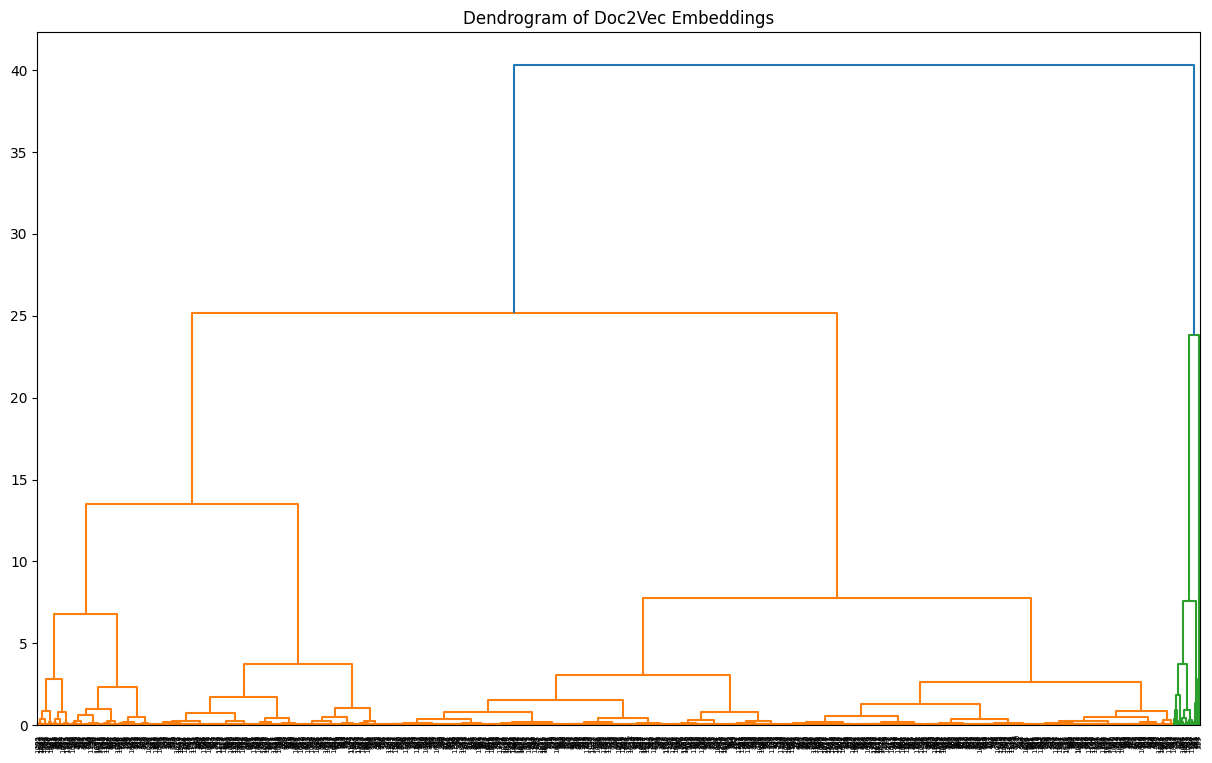

Dendrogram saved to /content/output_files/dendrogram.png


In [19]:
link_model = linkage(list(result_df['vector']), 'ward') #ward 병합 기준으로

plt.figure(figsize=(15,9))
dendrogram(link_model,
           orientation='top',
           distance_sort='descending',
            show_leaf_counts=False)

plt.title('Dendrogram of Doc2Vec Embeddings')

output_dir = '/content/output_files'
os.makedirs(output_dir, exist_ok=True)
dendrogram_filename = os.path.join(output_dir, 'dendrogram.png')
plt.savefig(dendrogram_filename)
plt.show()
print(f"Dendrogram saved to {dendrogram_filename}")
plt.close() # Close the plot to free memory

## UMAP

In [20]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


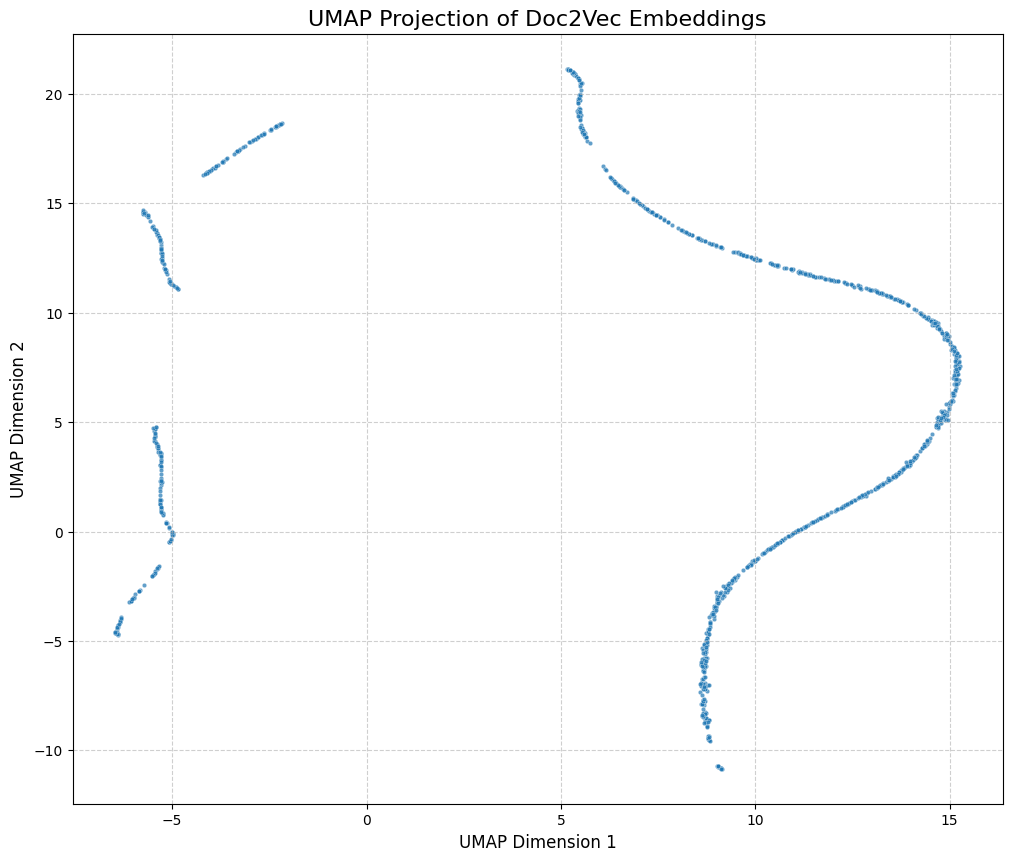

UMAP plot saved to /content/output_files/umap_projection.png


In [21]:
umap_reducer = umap.UMAP(n_components=2, random_state=42)

embedding = umap_reducer.fit_transform(list(result_df['vector']))

result_df['umap_x'] = embedding[:, 0]
result_df['umap_y'] = embedding[:, 1]

plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='umap_x',
    y='umap_y',
    data=result_df,
    s=10, # 점 크기
    alpha=0.7 # 투명도
)
plt.title('UMAP Projection of Doc2Vec Embeddings', fontsize=16)
plt.xlabel('UMAP Dimension 1', fontsize=12)
plt.ylabel('UMAP Dimension 2', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)


output_dir = '/content/output_files'
os.makedirs(output_dir, exist_ok=True)
umap_filename = os.path.join(output_dir, 'umap_projection.png')
plt.savefig(umap_filename)
plt.show()
print(f"UMAP plot saved to {umap_filename}")
plt.close() # Close the plot to free memory

## PCA

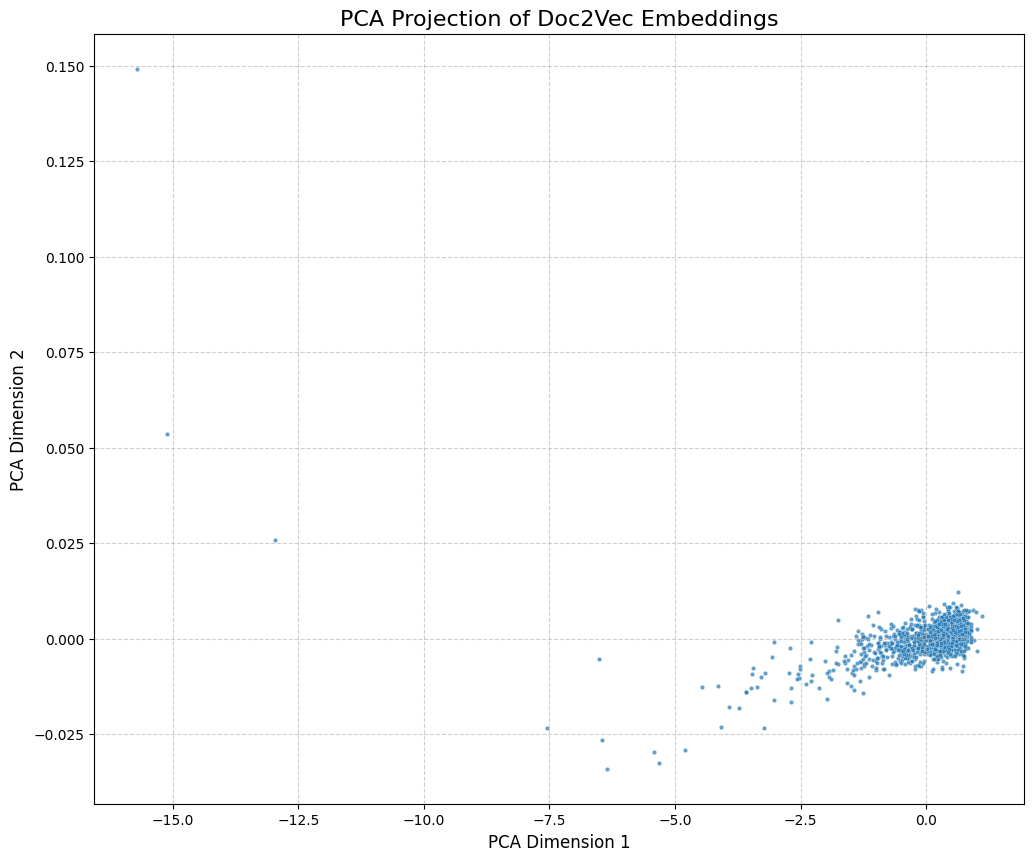

PCA plot saved to /content/output_files/pca_projection.png


In [22]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# PCA 모델 설정
# n_components는 시각화를 위해 2로 설정합니다.
pca = PCA(n_components=2, random_state=42)

# Doc2Vec 벡터에 PCA 적용
# result_df['vector']는 numpy array 형태로 변환되어야 합니다.
pca_embedding = pca.fit_transform(list(result_df['vector']))

# 차원 축소된 데이터를 DataFrame에 추가
result_df['pca_x'] = pca_embedding[:, 0]
result_df['pca_y'] = pca_embedding[:, 1]

# PCA 결과를 시각화
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='pca_x',
    y='pca_y',
    data=result_df,
    s=10, # 점 크기
    alpha=0.7 # 투명도
)
plt.title('PCA Projection of Doc2Vec Embeddings', fontsize=16)
plt.xlabel('PCA Dimension 1', fontsize=12)
plt.ylabel('PCA Dimension 2', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

output_dir = '/content/output_files'
os.makedirs(output_dir, exist_ok=True)
pca_filename = os.path.join(output_dir, 'pca_projection.png')
plt.savefig(pca_filename)
plt.show()
print(f"PCA plot saved to {pca_filename}")
plt.close() # Close the plot to free memory

## t-SNE

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


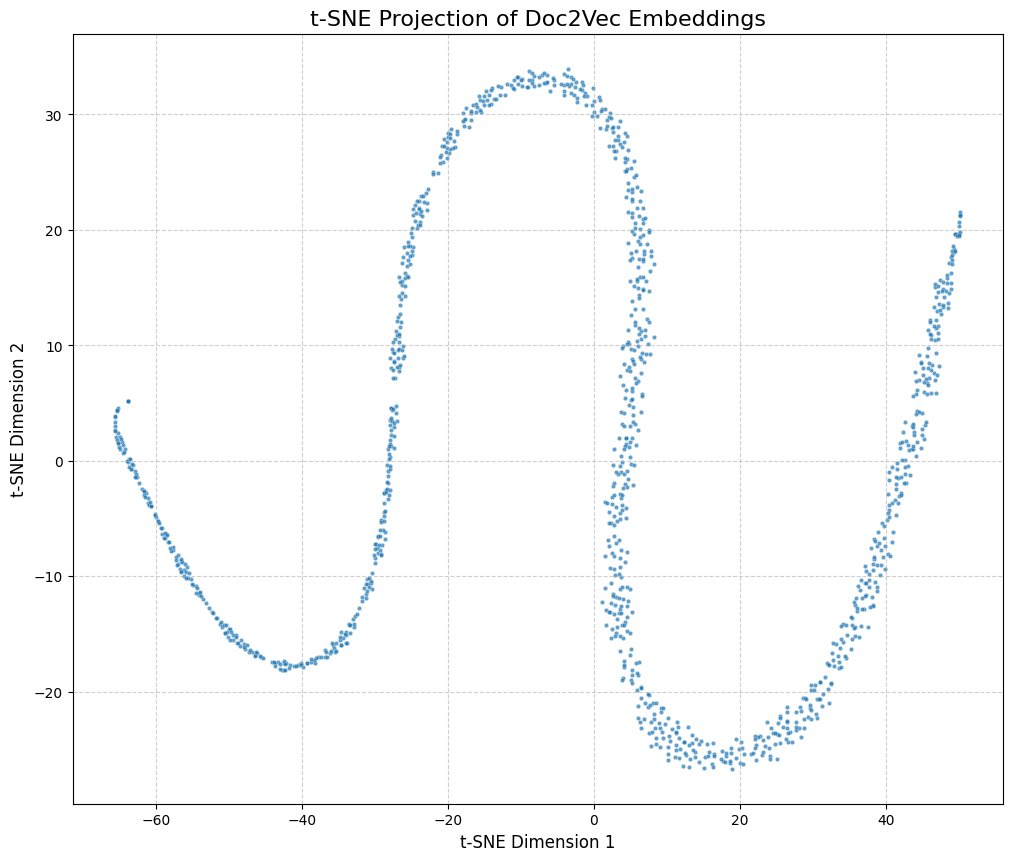

t-SNE plot saved to /content/output_files/tsne_projection.png


In [23]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # numpy import 추가

# t-SNE 모델 설정
# n_components는 시각화를 위해 2로 설정합니다.
# perplexity, learning_rate, n_iter 등의 파라미터는 데이터에 따라 조정이 필요할 수 있습니다.
# random_state를 설정하여 결과의 재현성을 확보합니다.
tsne_model = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate=200, n_iter=1000)

# Doc2Vec 벡터에 t-SNE 적용
# result_df['vector']는 numpy array 형태로 변환되어야 합니다.
# list(result_df['vector'])를 numpy 배열로 변환합니다.
tsne_embedding = tsne_model.fit_transform(np.array(list(result_df['vector'])))

# 차원 축소된 데이터를 DataFrame에 추가
result_df['tsne_x'] = tsne_embedding[:, 0]
result_df['tsne_y'] = tsne_embedding[:, 1]

# t-SNE 결과를 시각화
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='tsne_x',
    y='tsne_y',
    data=result_df,
    s=10, # 점 크기
    alpha=0.7 # 투명도
)
plt.title('t-SNE Projection of Doc2Vec Embeddings', fontsize=16)
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

output_dir = '/content/output_files'
os.makedirs(output_dir, exist_ok=True)
tsne_filename = os.path.join(output_dir, 'tsne_projection.png')
plt.savefig(tsne_filename)
plt.show()
print(f"t-SNE plot saved to {tsne_filename}")
plt.close() # Close the plot to free memory

In [24]:
from googleapiclient.discovery import build
from googleapiclient.http import MediaFileUpload
import zipfile

os.makedirs(output_dir, exist_ok=True)

# 1. 데이터프레임 저장 (CSV)
df_filename = os.path.join(output_dir, 'processed_data.csv')
df.to_csv(df_filename, index=False)
print(f"DataFrame saved to {df_filename}")

# 2. 모든 결과 파일을 하나의 ZIP 파일로 압축
zip_filename = os.path.join(output_dir, 'Doc2Vec.zip')
with zipfile.ZipFile(zip_filename, 'w') as zf:
    if os.path.exists(df_filename):
        zf.write(df_filename, os.path.basename(df_filename))
    if os.path.exists(os.path.join(output_dir, 'dendrogram.png')):
        zf.write(os.path.join(output_dir, 'dendrogram.png'), os.path.basename(os.path.join(output_dir, 'dendrogram.png')))
    if os.path.exists(os.path.join(output_dir, 'umap_projection.png')):
        zf.write(os.path.join(output_dir, 'umap_projection.png'), os.path.basename(os.path.join(output_dir, 'umap_projection.png')))
    if os.path.exists(os.path.join(output_dir, 'pca_projection.png')):
        zf.write(os.path.join(output_dir, 'pca_projection.png'), os.path.basename(os.path.join(output_dir, 'pca_projection.png')))
    if os.path.exists(os.path.join(output_dir, 'tsne_projection.png')):
        zf.write(os.path.join(output_dir, 'tsne_projection.png'), os.path.basename(os.path.join(output_dir, 'tsne_projection.png')))
print(f"All results compressed into {zip_filename}")

# 3. Google Drive API를 사용하여 ZIP 파일 업로드
# Colab의 내장 인증 방식을 사용합니다.
drive_service = build('drive', 'v3')

if os.path.exists(zip_filename):
    file_metadata = {
        'name': os.path.basename(zip_filename),
        'parents': [drive_folder_id]
    }
    media = MediaFileUpload(zip_filename, resumable=True)
    uploaded_file = drive_service.files().create(
        body=file_metadata,
        media_body=media,
        fields='id'
    ).execute()
    print(f"Uploaded '{os.path.basename(zip_filename)}' to Google Drive folder ID: {drive_folder_id}. File ID: {uploaded_file.get('id')}")
else:
    print(f"Warning: ZIP file not found for upload - {zip_filename}")

print("All specified files have been processed and uploaded to Google Drive as a ZIP archive.")

DataFrame saved to /content/output_files/processed_data.csv
All results compressed into /content/output_files/Doc2Vec.zip
Uploaded 'Doc2Vec.zip' to Google Drive folder ID: 1teiRbwW4ciSrKLd4bvs7kc81Y5q3lkwV. File ID: 1ybHddIFSLCDOWnjaKf6OWe1Ab78_vcle
All specified files have been processed and uploaded to Google Drive as a ZIP archive.
